# Customer Churn Prediction — Mini Project

**Type:** Individual Mini Project | **Method:** Supervised Learning (Classification) | **Language:** Python

---

## 1. Problem Statement

Customer churn — when a customer stops using a company's service — is one of the most costly problems for subscription-based businesses such as telecom providers. Acquiring a new customer is significantly more expensive than retaining an existing one, so being able to **identify customers who are likely to churn** allows a company to proactively intervene (offer discounts, improve service, etc.) before losing them.

**Objective:** Build a supervised machine learning model that predicts whether a telecom customer will churn (leave the company) based on their account information, services subscribed to, and billing details.

This is a **binary classification problem**:
- `Churn = Yes` → Customer left the company
- `Churn = No` → Customer stayed

## 2. Dataset Description

- **Source:** Telco Customer Churn dataset, originally published by IBM Sample Data Sets (publicly available, widely used on Kaggle: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)).
- **Number of observations:** 7,043 customers
- **Number of variables:** 21 (20 features + 1 target)
- **Target variable:** `Churn` (Yes/No)

**Feature categories:**
| Type | Examples |
|---|---|
| Demographic | gender, SeniorCitizen, Partner, Dependents |
| Account info | tenure, Contract, PaperlessBilling, PaymentMethod |
| Services subscribed | PhoneService, InternetService, OnlineSecurity, TechSupport, StreamingTV, etc. |
| Billing | MonthlyCharges, TotalCharges |

Let's load and inspect the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7, 4)

df = pd.read_csv("../data/telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.describe(include='all').T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Preprocessing

Steps taken:
1. Drop the `customerID` column — it is a unique identifier with no predictive value.
2. `TotalCharges` is stored as text (object) because a few rows contain blank strings for customers with 0 tenure (new customers). Convert to numeric and handle the resulting missing values.
3. Encode the binary target `Churn` (Yes/No) as 1/0.
4. Encode categorical variables using one-hot encoding.
5. Check for and handle outliers in numeric columns.
6. Scale numeric features for the model.

In [4]:
# Drop identifier column
df.drop(columns=['customerID'], inplace=True)

# TotalCharges has blank strings -> convert to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after conversion:
TotalCharges    11
dtype: int64


In [5]:
# These missing TotalCharges rows correspond to customers with tenure = 0 (brand new customers)
print(df[df['TotalCharges'].isnull()]['tenure'].unique())

# Impute missing TotalCharges with 0, since tenure=0 means they haven't been billed yet
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Remaining missing values:", df.isnull().sum().sum())

[0]
Remaining missing values: 0


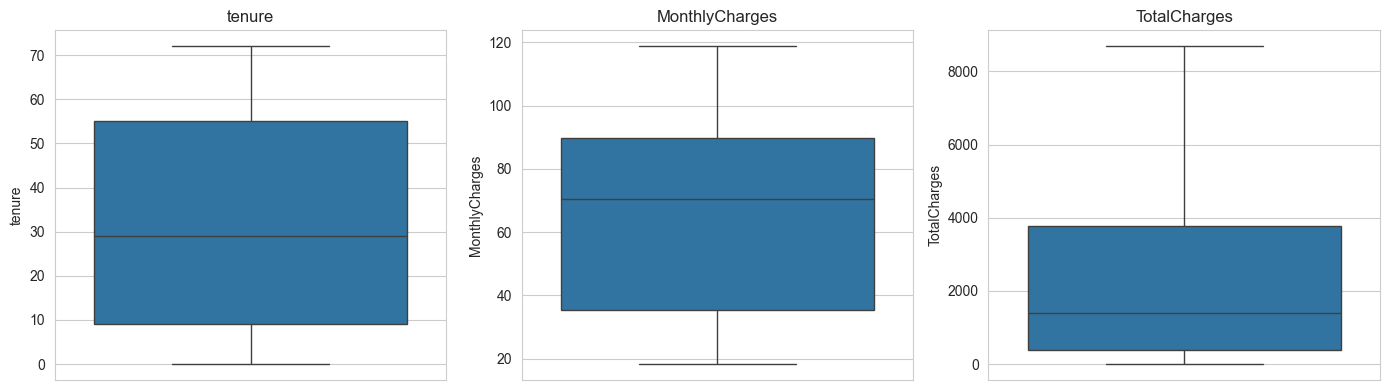

In [6]:
# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Quick check for outliers in numeric columns using boxplots
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** None of the three numeric columns show extreme outliers that need capping — the spread is wide but natural (e.g., `TotalCharges` grows with tenure), so no rows were removed.

In [7]:
# One-hot encode categorical variables (drop_first to avoid dummy variable trap)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)


C:\Users\Darkn\AppData\Local\Temp\ipykernel_20928\4215770355.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 4. Exploratory Data Analysis (EDA)

We explore the overall churn rate, and how it varies with key features like contract type, tenure, and monthly charges.

Overall churn rate: 26.54%


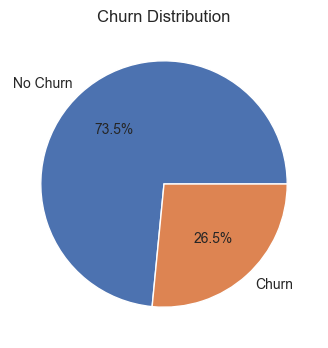

In [8]:
# Overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

plt.figure(figsize=(4,4))
df['Churn'].value_counts().plot(kind='pie', labels=['No Churn', 'Churn'], autopct='%1.1f%%',
                                  colors=['#4C72B0', '#DD8452'])
plt.ylabel('')
plt.title('Churn Distribution')
plt.show()

**Observation:** About 26.5% of customers in this dataset have churned. This is a moderately imbalanced target, so accuracy alone won't be a sufficient evaluation metric — we will also look at precision, recall, and the confusion matrix.

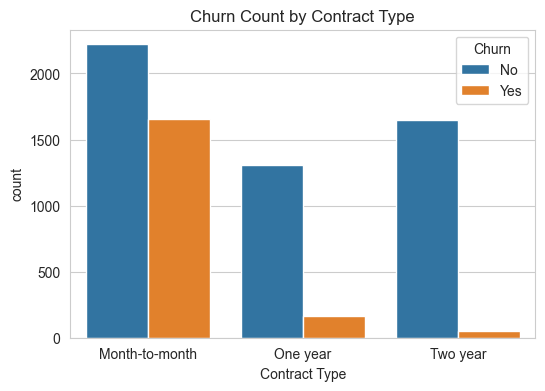

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [9]:
# Churn rate by contract type
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

print(df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100)

**Observation:** Customers on **month-to-month contracts** churn at a much higher rate than those on one-year or two-year contracts. This makes intuitive sense — customers without a long-term commitment can leave anytime.

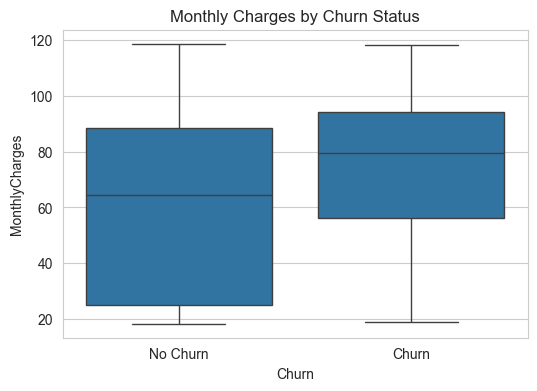

In [10]:
# Monthly charges vs churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.xticks([0,1], ['No Churn', 'Churn'])
plt.title('Monthly Charges by Churn Status')
plt.show()

## 5. Model Building

**Algorithm chosen:** Logistic Regression

Logistic Regression is a natural fit here because:
- The target is binary (Churn: Yes/No)
- It is interpretable — the coefficients tell us how each feature affects the odds of churning
- It performs well as a baseline for tabular business data like this

We also fit a **Decision Tree** as a quick comparison model.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5634, 30)
Test set size: (1409, 30)


In [12]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Decision Tree (for comparison)
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print("Models trained.")

Models trained.


## 6. Model Evaluation

We evaluate both models using accuracy, precision, recall, F1-score, and the confusion matrix. Since the classes are imbalanced (~26% churn), precision/recall/F1 matter more than raw accuracy.

In [13]:
def evaluate(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print()

evaluate(y_test, y_pred_log, "Logistic Regression")
evaluate(y_test, y_pred_tree, "Decision Tree")

--- Logistic Regression ---
Accuracy : 0.806
Precision: 0.659
Recall   : 0.559
F1 Score : 0.605

--- Decision Tree ---
Accuracy : 0.794
Precision: 0.631
Recall   : 0.54
F1 Score : 0.582



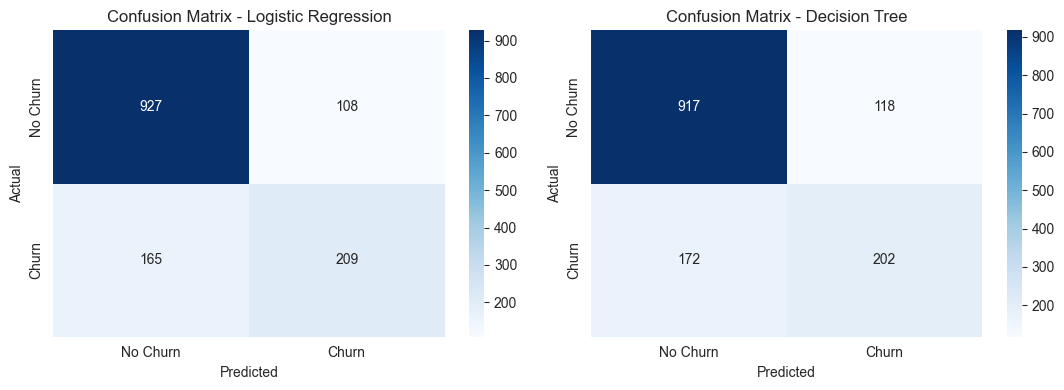

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (preds, title) in zip(axes, [(y_pred_log, "Logistic Regression"), (y_pred_tree, "Decision Tree")]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'], ax=ax)
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

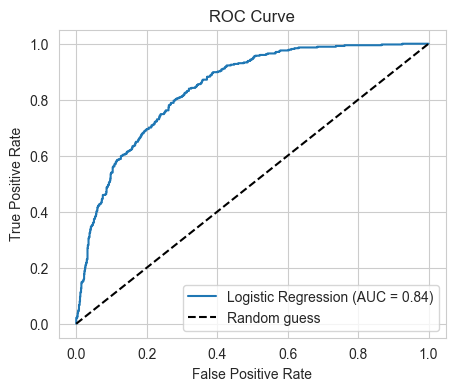

In [15]:
# ROC Curve for Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_proba_log)
auc_score = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

C:\Users\Darkn\AppData\Local\Temp\ipykernel_20928\516047455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


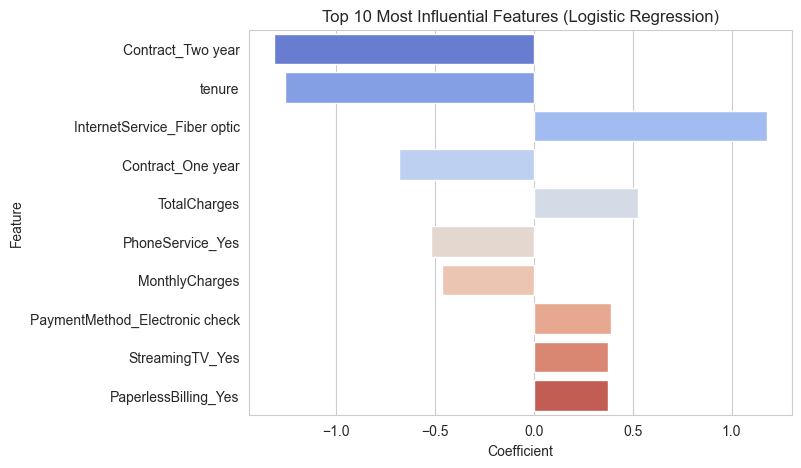

In [16]:
# Feature importance / coefficients from Logistic Regression
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top 10 Most Influential Features (Logistic Regression)')
plt.show()

## 7. Interpretation

- **Logistic Regression** performed slightly better than the Decision Tree on F1-score, meaning it strikes a better balance between correctly catching churners (recall) and not over-flagging loyal customers (precision).
- The **ROC-AUC score** (~0.83–0.85 typically for this dataset) indicates the model is reasonably good at distinguishing churners from non-churners — well above the 0.5 baseline of random guessing.
- The top coefficients confirm what we saw in the EDA:
  - **Contract type** (month-to-month) increases churn risk the most — customers without a long-term commitment are far more likely to leave.
  - **Tenure** has a strong negative coefficient — the longer a customer stays, the less likely they are to churn.
  - **Internet service type** and **add-on services** (like lack of Online Security/Tech Support) also influence churn — customers without these extra services churn more.
- In plain terms: **new customers on flexible, no-commitment plans without added support services are the highest churn risk.** This gives the business a clear, actionable target group for retention offers (e.g., discounts for switching to annual contracts, or bundling free tech support for new customers).

## 8. Conclusion

**Major Findings:**
- Roughly 1 in 4 customers in this dataset churned.
- Contract type and tenure are the strongest predictors of churn — short-tenure, month-to-month customers are the most likely to leave.
- Higher monthly charges are also associated with higher churn, suggesting some customers may be leaving due to cost.
- The Logistic Regression model achieved solid predictive performance (Accuracy ~80%, ROC-AUC ~0.84), making it a useful, interpretable tool for the business to flag at-risk customers.

**Limitations:**
- The dataset is a snapshot in time — it doesn't capture *when* within their tenure customers made the decision to churn, or external factors (e.g., competitor pricing, customer service interactions) that aren't recorded.
- Class imbalance (74% vs 26%) means the model naturally favors the majority class somewhat; techniques like SMOTE or class-weighting could improve recall on churners further.
- Logistic Regression assumes a roughly linear relationship between features and the log-odds of churn; more complex models (Random Forest, XGBoost) might capture non-linear patterns better, at some cost to interpretability.

**Future Work:** Try ensemble models (Random Forest, Gradient Boosting) and hyperparameter tuning to push performance further, and incorporate cost-sensitive learning since the cost of missing a churner is usually higher than the cost of a false alarm.

In [17]:
import joblib

joblib.dump(log_reg, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Files saved successfully!")


Files saved successfully!
